In [2]:
import sys, importlib, os

_src_training = os.path.dirname(os.path.abspath("training.ipynb"))
_src = os.path.dirname(_src_training)
for _p in [_src_training, _src]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import infrastructure, pipeline, classifier, evaluation
for _mod in [infrastructure, pipeline, classifier, evaluation]:
    importlib.reload(_mod)

from infrastructure import clean_neo4j_db, clean_kafka_topics, delete_test_neo4j_nodes, verify_concept_created
from pipeline import train_mnist, remove_concept, retrain_concept
from evaluation import test_mnist_all
from classifier import classify_image
import json, uuid
print("Modules loaded.")

ModuleNotFoundError: No module named 'infrastructure'

In [ ]:
classes_to_subclasses = {
    0: [1],
    1: [1, 3],
    2: [1, 2],
    3: [1],
    4: [1, 2],
    5: [1],
    6: [1],
    7: [1],
    8: [1],
    9: [2],
}

In [ ]:
clean_neo4j_db()
#clean_kafka_topics()

for class_num in classes_to_subclasses:
    for subclass in classes_to_subclasses[class_num]:
        train_mnist(class_number=class_num, subclass=subclass, is_prepared_samples=True, with_concept_creation=True)

In [14]:
# ── Restore concepts from JSON snapshot into Neo4j ──
# Uncomment and run this cell to load your colleague's concepts
# This will REPLACE all existing concepts in Neo4j

import json as _json
from neo4j import GraphDatabase

SNAPSHOT_PATH = "../../concept_graphs.json"

_uri = os.environ.get("NEO4J_DSN", "bolt://localhost:7687")
_user = os.environ.get("NEO4J_USER", "neo4j")
_pw = os.environ.get("NEO4J_PASSWORD", "111122223333")

with open(SNAPSHOT_PATH) as f:
    snapshot = _json.load(f)

driver = GraphDatabase.driver(_uri, auth=(_user, _pw))

# Clean existing concepts
with driver.session() as session:
    session.run("MATCH (n) WHERE n.concept_id IS NOT NULL DETACH DELETE n")
    print("Cleared existing concepts from Neo4j.")

for cid, gdata in snapshot.items():
    nodes = gdata.get("nodes", [])
    edges = gdata.get("edges", gdata.get("links", []))

    # Map old node IDs to new ones
    id_map = {}
    with driver.session() as session:
        for node in nodes:
            labels = node.get("labels", [])
            label_str = ":".join(labels)
            props = {}
            for k, v in node.items():
                if k in ("labels",):
                    continue
                if isinstance(v, (dict, list)):
                    props[k] = _json.dumps(v)
                else:
                    props[k] = v
            old_id = node.get("id", node.get("uuid"))
            result = session.run(
                f"CREATE (n:{label_str} $props) RETURN elementId(n) AS nid",
                props=props
            )
            new_id = result.single()["nid"]
            id_map[old_id] = new_id

        for edge in edges:
            src = id_map.get(edge["source"])
            tgt = id_map.get(edge["target"])
            rel_type = edge.get("type", "CONNECTED_TO")
            if src and tgt:
                session.run(
                    f"MATCH (a), (b) WHERE elementId(a) = $src AND elementId(b) = $tgt "
                    f"CREATE (a)-[:{rel_type}]->(b)",
                    src=src, tgt=tgt
                )

    print(f"  Restored concept {cid}: {len(nodes)} nodes, {len(edges)} edges")

driver.close()
print(f"\nDone. Restored {len(snapshot)} concepts from {SNAPSHOT_PATH}")

Cleared existing concepts from Neo4j.
  Restored concept 0_1: 10 nodes, 10 edges
  Restored concept 1_1: 5 nodes, 4 edges
  Restored concept 1_3: 3 nodes, 2 edges
  Restored concept 2_1: 7 nodes, 6 edges
  Restored concept 2_2: 10 nodes, 10 edges
  Restored concept 3_1: 11 nodes, 10 edges
  Restored concept 4_1: 8 nodes, 8 edges
  Restored concept 4_2: 7 nodes, 6 edges
  Restored concept 5_1: 9 nodes, 8 edges
  Restored concept 6_1: 10 nodes, 10 edges
  Restored concept 7_1: 5 nodes, 4 edges
  Restored concept 8_1: 13 nodes, 14 edges
  Restored concept 9_2: 8 nodes, 8 edges

Done. Restored 13 concepts from ../../concept_graphs.json


Loaded 13 concepts from Neo4j
  0_1: 10 nodes, 10 edges
  1_1: 5 nodes, 4 edges
  1_3: 3 nodes, 2 edges
  2_1: 7 nodes, 6 edges
  2_2: 10 nodes, 10 edges
  3_1: 11 nodes, 10 edges
  4_1: 8 nodes, 8 edges
  4_2: 7 nodes, 6 edges
  5_1: 9 nodes, 8 edges
  6_1: 10 nodes, 10 edges
  7_1: 5 nodes, 4 edges
  8_1: 13 nodes, 14 edges
  9_2: 8 nodes, 8 edges


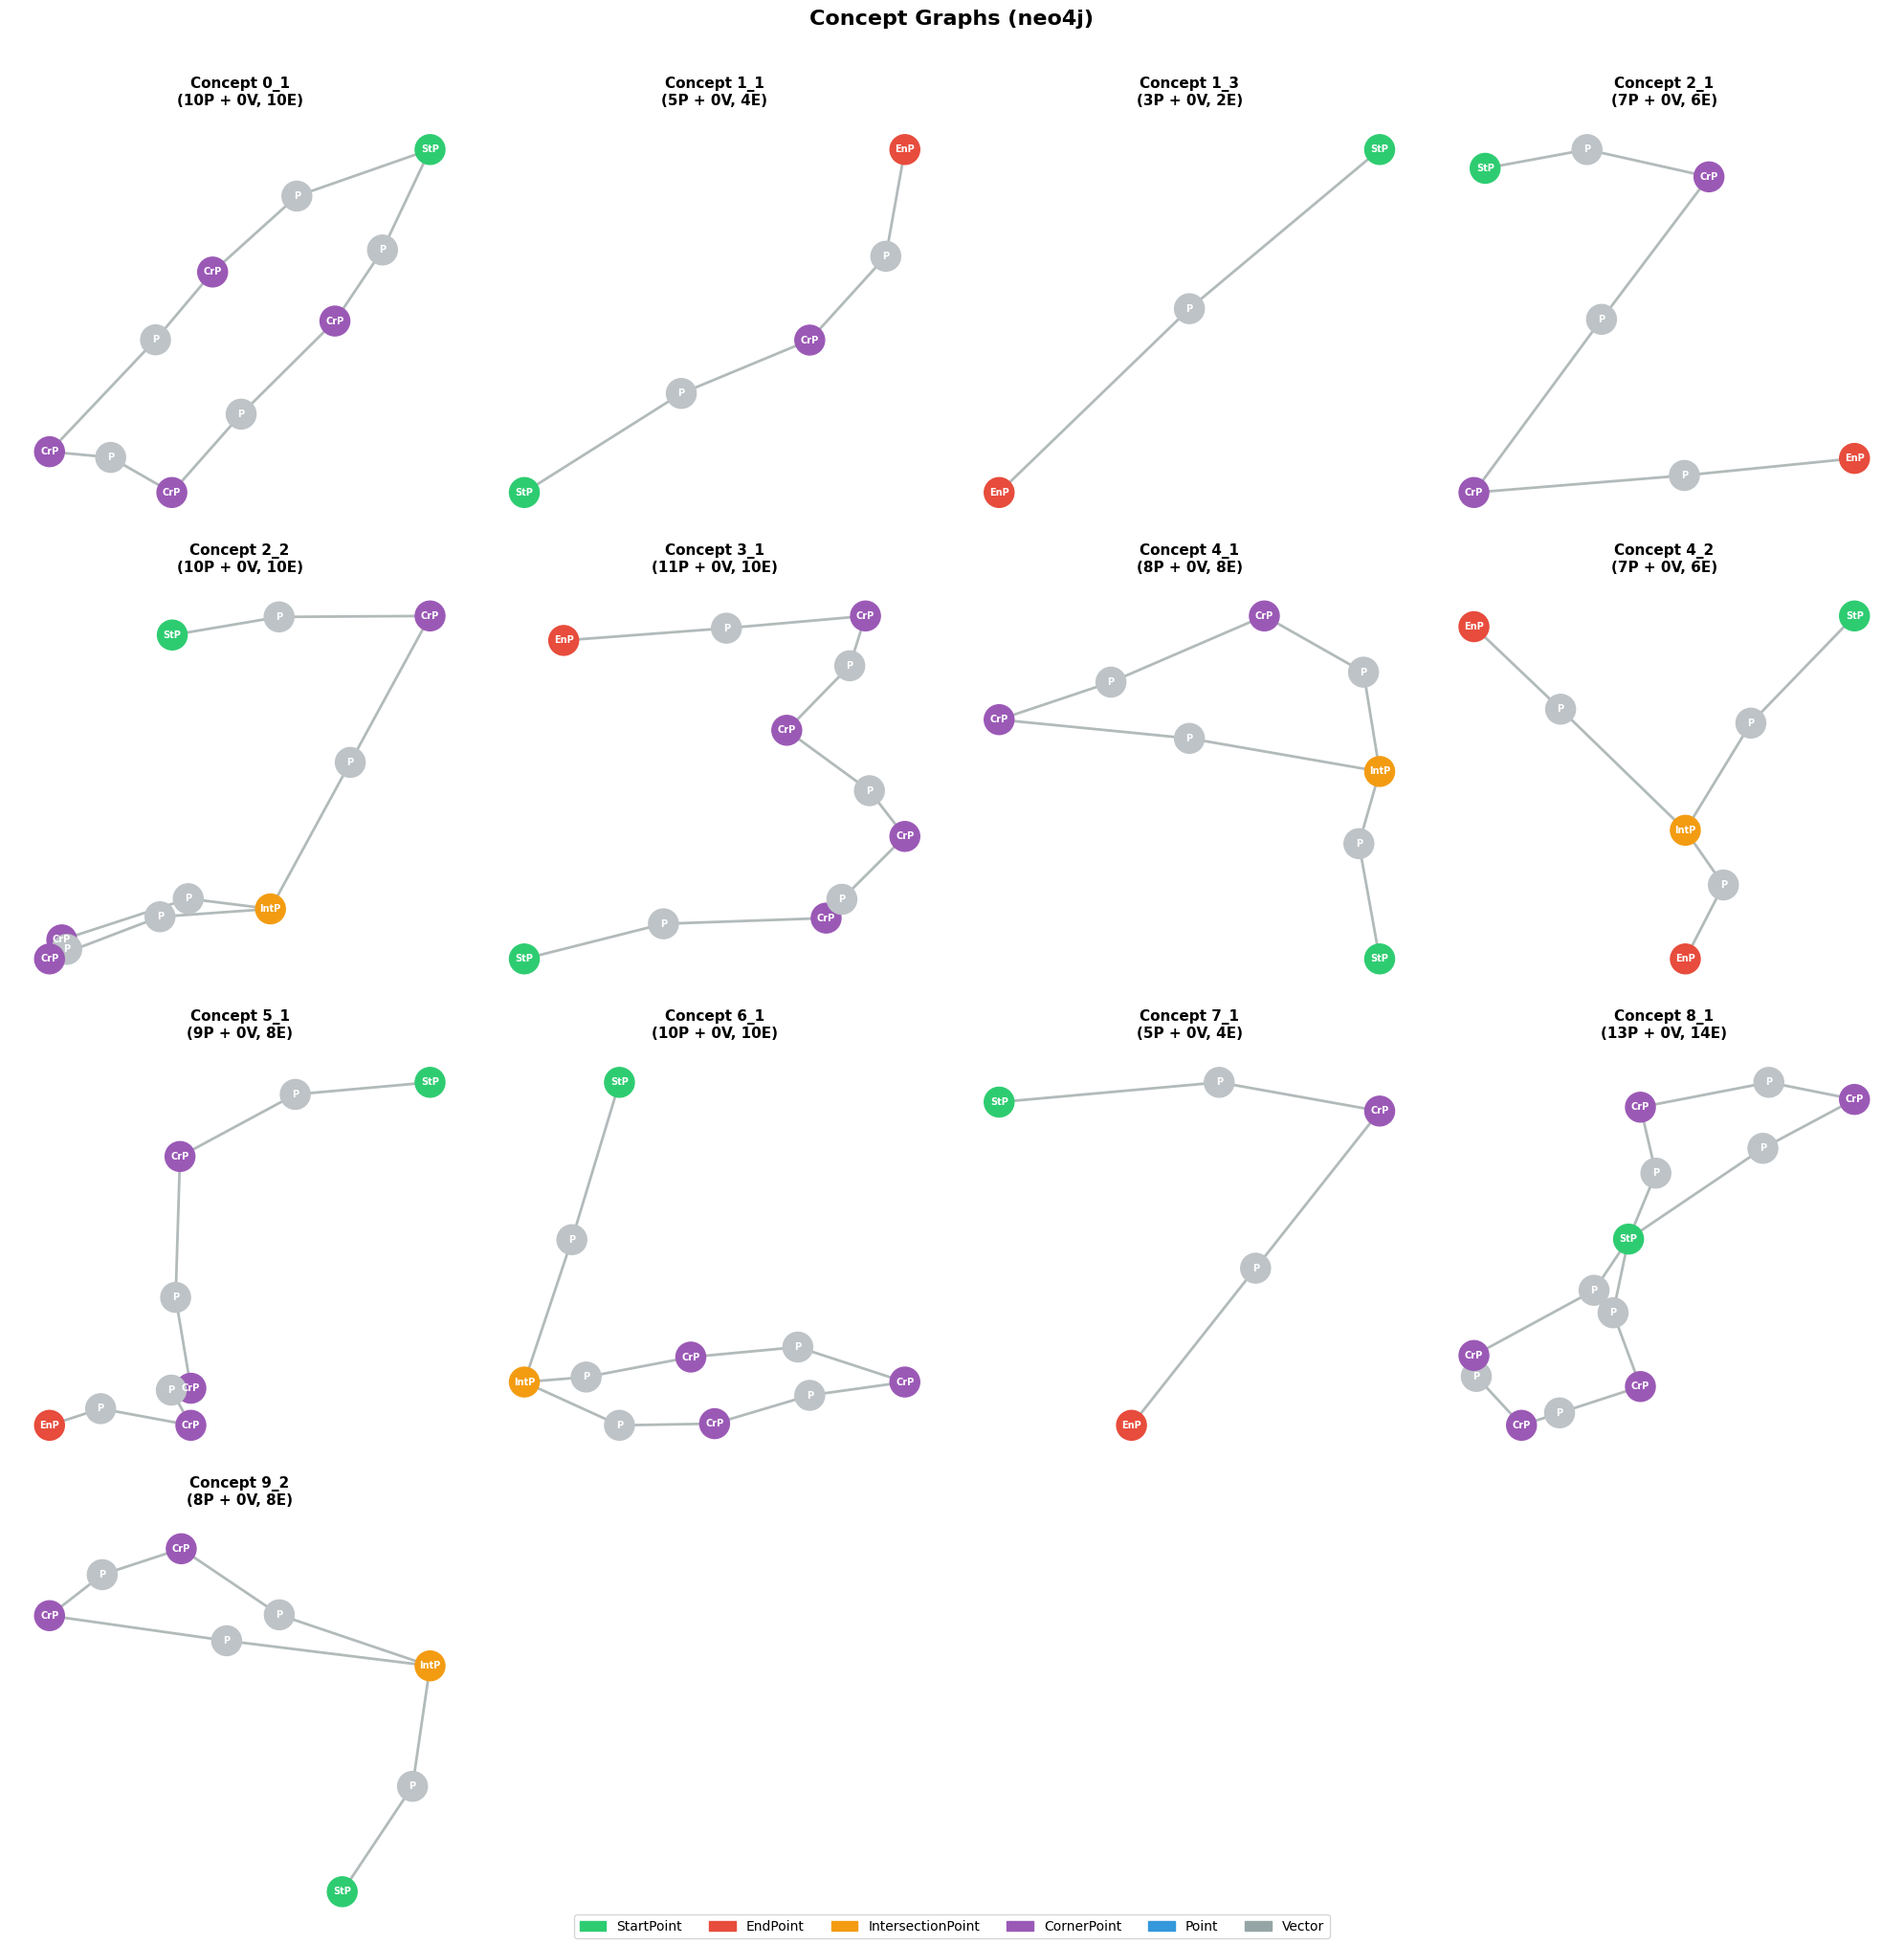

In [15]:
# ── Visualize concept graphs (from Neo4j or JSON snapshot) ──
import json as _json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from neo4j import GraphDatabase

# Set SOURCE: "neo4j" to load from database, or path to JSON file
SOURCE = "neo4j"
# SOURCE = "../../concept_graphs.json"  # uncomment to load colleague's snapshot

LABEL_COLORS = {
    "StartPoint": "#2ecc71", "EndPoint": "#e74c3c",
    "IntersectionPoint": "#f39c12", "CornerPoint": "#9b59b6",
    "Point": "#3498db", "Vector": "#95a5a6",
}


def get_node_color(labels):
    for l in ["StartPoint", "EndPoint", "IntersectionPoint", "CornerPoint", "Point", "Vector"]:
        if l in labels:
            return LABEL_COLORS[l]
    return "#bdc3c7"

def get_label_abbrev(labels):
    for l, abbr in [("StartPoint","StP"), ("EndPoint","EnP"), ("IntersectionPoint","IntP"),
                     ("CornerPoint","CrP"), ("HorizontalVector","H"), ("VerticalVector","V"), ("Vector","Vec")]:
        if l in labels:
            return abbr
    return "P"

def parse_coord(val):
    if val is None:
        return None
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        try: return float(val)
        except ValueError: pass
        try:
            d = _json.loads(val)
            if isinstance(d, dict) and "center" in d:
                return float(d["center"])
        except Exception: pass
    if isinstance(val, dict) and "center" in val:
        return float(val["center"])
    return None

def load_from_neo4j():
    uri = os.environ.get("NEO4J_DSN", "bolt://localhost:7687")
    user = os.environ.get("NEO4J_USER", "neo4j")
    pw = os.environ.get("NEO4J_PASSWORD", "111122223333")
    driver = GraphDatabase.driver(uri, auth=(user, pw))
    with driver.session() as session:
        cids = [r["cid"] for r in session.run(
            "MATCH (n) WHERE n.concept_id IS NOT NULL RETURN DISTINCT n.concept_id AS cid ORDER BY cid")]
    graphs = {}
    for cid in cids:
        with driver.session() as session:
            records = list(session.run("""
                MATCH (n) WHERE n.concept_id = $cid
                OPTIONAL MATCH (n)-[r]-(m {concept_id: $cid})
                RETURN elementId(n) AS node_id, labels(n) AS labels, properties(n) AS props,
                       type(r) AS rel_type, elementId(m) AS target_id
            """, cid=cid))
        G = nx.Graph()
        for rec in records:
            nid = rec["node_id"]
            if nid not in G:
                G.add_node(nid, labels=set(rec["labels"]), **rec["props"])
            if rec["target_id"] and rec["target_id"] != nid:
                G.add_edge(nid, rec["target_id"])
        graphs[cid] = G
    driver.close()
    return graphs

def load_from_json(path):
    with open(path) as f:
        data = _json.load(f)
    graphs = {}
    for cid, gdata in data.items():
        G = nx.Graph()
        for n in gdata.get("nodes", []):
            nid = n.get("id", n.get("uuid", str(id(n))))
            labels = set(n.get("labels", []))
            G.add_node(nid, labels=labels, **{k: v for k, v in n.items() if k not in ("id", "labels")})
        for e in gdata.get("edges", gdata.get("links", [])):
            G.add_edge(e["source"], e["target"])
        graphs[cid] = G
    return graphs

# Load concepts
if SOURCE == "neo4j":
    concept_graphs = load_from_neo4j()
    print(f"Loaded {len(concept_graphs)} concepts from Neo4j")
else:
    concept_graphs = load_from_json(SOURCE)
    print(f"Loaded {len(concept_graphs)} concepts from {SOURCE}")

for cid, G in concept_graphs.items():
    print(f"  {cid}: {len(G.nodes)} nodes, {len(G.edges)} edges")

# Compute positions
def compute_positions(G):
    pos = {}
    for node, data in G.nodes(data=True):
        nx_val = parse_coord(data.get("normalized_x"))
        ny_val = parse_coord(data.get("normalized_y"))
        if nx_val is not None and ny_val is not None:
            pos[node] = (nx_val, -ny_val)
    for node in G.nodes:
        if node in pos:
            continue
        neighbors = [n for n in G.neighbors(node) if n in pos]
        if neighbors:
            ax = sum(pos[n][0] for n in neighbors) / len(neighbors)
            ay = sum(pos[n][1] for n in neighbors) / len(neighbors)
            pos[node] = (ax + 0.03 * (hash(str(node)) % 5 - 2), ay + 0.03 * (hash(str(node)) % 7 - 3))
        else:
            pos[node] = (0, 0)
    return pos

# Plot
concept_ids = sorted(concept_graphs.keys())
n = len(concept_ids)
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
if rows == 1 and cols == 1: axes = [[axes]]
elif rows == 1: axes = [axes]
elif cols == 1: axes = [[a] for a in axes]

for idx, cid in enumerate(concept_ids):
    ax = axes[idx // cols][idx % cols]
    G = concept_graphs[cid]
    if not G.nodes:
        ax.set_title(f"Concept {cid}\n(empty)"); ax.axis("off"); continue

    pos = compute_positions(G)

    points = [n for n in G.nodes if "Vector" not in G.nodes[n].get("labels", set())]
    vectors = [n for n in G.nodes if "Vector" in G.nodes[n].get("labels", set())]

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#7f8c8d", width=2, alpha=0.6)
    if points:
        nx.draw_networkx_nodes(G, pos, nodelist=points, ax=ax, node_shape="o", node_size=500,
                               node_color=[get_node_color(G.nodes[n].get("labels", set())) for n in points])
    if vectors:
        nx.draw_networkx_nodes(G, pos, nodelist=vectors, ax=ax, node_shape="s", node_size=200,
                               node_color=[get_node_color(G.nodes[n].get("labels", set())) for n in vectors])

    labels = {n: get_label_abbrev(G.nodes[n].get("labels", set())) for n in G.nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=7, font_color="white", font_weight="bold")

    ax.set_title(f"Concept {cid}\n({len(points)}P + {len(vectors)}V, {len(G.edges)}E)", fontsize=11, fontweight="bold")
    ax.axis("off")

for idx in range(n, rows * cols):
    axes[idx // cols][idx % cols].axis("off")

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
fig.legend(handles=legend_patches, loc="lower center", ncol=len(legend_patches), fontsize=10)
plt.suptitle(f"Concept Graphs ({SOURCE})", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
params = {
    "ged_timeout": 5,
    "skeletonization_threshold": 180,
    "comparison_method": "fgw",
    "fgw_alpha": 0.6,
    "property_normalizers": {
        "normalized_x": 3.0,
        "normalized_y": 3.0,
        "horizontal_direction": 2.0,
        "vertical_direction": 2.0,
        "cycle_count": 1.0,
        "angle_with_ox": 45,
    },
}
results, y_true, y_pred, run_dir = test_mnist_all(
    classes=list(classes_to_subclasses.keys()),
    params=params,
    sample_fraction=1.0,
    description="Testing after retraining with the new concept formation with fgw method",
)

In [17]:
# ── Experiment: Test on MNIST-all (10k images from datasets/mnist_all/) ──
# Copies images into tests/ so nuclio containers can access them via volume mount
import os, pathlib, shutil

_project_root = pathlib.Path(os.path.abspath("training.ipynb")).parent.parent.parent
_src_dir = _project_root / "datasets" / "mnist_all"
_dst_dir = _project_root / "tests" / "mnist_all"

# Remove old symlink if it exists, then copy
if _dst_dir.is_symlink():
    _dst_dir.unlink()

if not _dst_dir.exists():
    print(f"Copying {_src_dir} -> {_dst_dir} ...")
    shutil.copytree(_src_dir, _dst_dir)
    print(f"Done. Copied {sum(1 for _ in _dst_dir.rglob('*.png'))} images.")
    
else:
    print(f"Directory already exists: {_dst_dir}")

params_mnist_all = {
    "ged_timeout": 5,
    "skeletonization_threshold": 180,
    "comparison_method": "fgw",
    "fgw_alpha": 0.6,
    "property_normalizers": {
        "normalized_x": 3.0,
        "normalized_y": 3.0,
        "horizontal_direction": 2.0,
        "vertical_direction": 2.0,
        "cycle_count": 1.0,
        "angle_with_ox": 45,
    },
}

results_mnist_all, y_true_mnist_all, y_pred_mnist_all, run_dir_mnist_all = test_mnist_all(
    classes=list(classes_to_subclasses.keys()),
    params=params_mnist_all,
    sample_fraction=1.0,
    description="Experiment: MNIST-all 10k test set from datasets/mnist_all",
    local_path_template=str(_dst_dir / "{cls}"),
    nuclio_volume_path_template="/opt/nuclio/shared_storage/mnist_all/{cls}",
)

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL () { ... }', position=<SummaryInputPosition line=2, column=1, offset=1>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1, 'line': 2, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nCALL {\n    MATCH (n:Point {concept_id: $concept_id}) RETURN n\n    UNION ALL\n    MATCH (n:Vector {concept_id: $concept_id}) RETURN n\n    UNION ALL\n    MATCH (n:StartPoint {concept_id: $concept_id}) RETURN n\n}\nWITH n, labels(n) AS node_labels, properties(n) as node_props\nOPTIONAL MATCH (n)-[r]-(m {concept_id: $concept_id})\nWITH n, node_

Directory already exists: /Users/kyrylo/Documents/git/NaturalAGI/tests/mnist_all


2026/03/17 22:38:16 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/17 22:38:16 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Classifying:   0%|          | 0/10000 [00:00<?, ?it/s]

/Users/kyrylo/Documents/git/NaturalAGI/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kyrylo/Documents/git/NaturalAGI/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Total: 10000  |  DLQ: 3  |  Success: 9997
Accuracy:  28.15%
Precision: 44.36%
Recall:    28.15%
F1:        20.44%

Results saved to: /Users/kyrylo/Documents/git/NaturalAGI/src/training/training_results/run_20260317_223816


2026/03/17 22:41:04 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/03/17 22:41:04 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run run_20260317_223816 at: http://localhost:5050/#/experiments/1/runs/89e8ff1ce5cd4f0985889e234a73ac99
🧪 View experiment at: http://localhost:5050/#/experiments/1


In [18]:
# ── Experiment: Test on manifest "complete" images only ──
# Filters datasets/manifest.csv for structure=="complete", copies only those
# images into tests/ so nuclio containers can access them.
import os, pathlib, shutil
import pandas as pd

_project_root = pathlib.Path(os.path.abspath("training.ipynb")).parent.parent.parent
_datasets_dir = _project_root / "datasets"
_manifest = pd.read_csv(_datasets_dir / "manifest.csv")

# Filter for complete images only
_complete = _manifest[_manifest["structure"] == "complete"].copy()
print(f"Total 'complete' images in manifest: {len(_complete)}")
print(f"Per class:\n{_complete['class'].value_counts().sort_index().to_string()}")

# Build a filtered directory with copies: tests/manifest_complete/{cls}/
_filtered_root = _project_root / "tests" / "manifest_complete"
if _filtered_root.exists():
    shutil.rmtree(_filtered_root)

copied = 0
for _, row in _complete.iterrows():
    cls = int(row["class"])
    src_image = _datasets_dir / row["image_path"]
    if not src_image.exists():
        continue
    dst_dir = _filtered_root / str(cls)
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst_file = dst_dir / src_image.name
    if not dst_file.exists():
        shutil.copy2(src_image, dst_file)
        copied += 1

print(f"Copied {copied} images to {_filtered_root}")
for d in sorted(_filtered_root.iterdir()):
    if d.is_dir():
        print(f"  Class {d.name}: {len(list(d.iterdir()))} images")

params_complete = {
    "ged_timeout": 5,
    "skeletonization_threshold": 180,
    "comparison_method": "fgw",
    "fgw_alpha": 0.6,
    "property_normalizers": {
        "normalized_x": 3.0,
        "normalized_y": 3.0,
        "horizontal_direction": 2.0,
        "vertical_direction": 2.0,
        "cycle_count": 1.0,
        "angle_with_ox": 45,
    },
}

results_complete, y_true_complete, y_pred_complete, run_dir_complete = test_mnist_all(
    classes=list(classes_to_subclasses.keys()),
    params=params_complete,
    sample_fraction=1.0,
    description="Experiment: manifest 'complete' images only (curated test set)",
    local_path_template=str(_filtered_root / "{cls}"),
    nuclio_volume_path_template="/opt/nuclio/shared_storage/manifest_complete/{cls}",
)

Total 'complete' images in manifest: 7794
Per class:
class
0    997
1    994
2    948
3    984
4    494
5    480
6    750
7    987
8    372
9    788


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. CALL subquery without a variable scope clause is deprecated. Use CALL () { ... }', position=<SummaryInputPosition line=2, column=1, offset=1>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1, 'line': 2, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nCALL {\n    MATCH (n:Point {concept_id: $concept_id}) RETURN n\n    UNION ALL\n    MATCH (n:Vector {concept_id: $concept_id}) RETURN n\n    UNION ALL\n    MATCH (n:StartPoint {concept_id: $concept_id}) RETURN n\n}\nWITH n, labels(n) AS node_labels, properties(n) as node_props\nOPTIONAL MATCH (n)-[r]-(m {concept_id: $concept_id})\nWITH n, node_

Copied 7794 images to /Users/kyrylo/Documents/git/NaturalAGI/tests/manifest_complete
  Class 0: 997 images
  Class 1: 994 images
  Class 2: 948 images
  Class 3: 984 images
  Class 4: 494 images
  Class 5: 480 images
  Class 6: 750 images
  Class 7: 987 images
  Class 8: 372 images
  Class 9: 788 images


2026/03/17 22:41:54 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/03/17 22:41:54 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Classifying:   0%|          | 0/7794 [00:00<?, ?it/s]

/Users/kyrylo/Documents/git/NaturalAGI/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/kyrylo/Documents/git/NaturalAGI/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Total: 7794  |  DLQ: 17  |  Success: 7777
Accuracy:  68.52%
Precision: 74.77%
Recall:    68.52%
F1:        69.03%

Results saved to: /Users/kyrylo/Documents/git/NaturalAGI/src/training/training_results/run_20260317_224153


2026/03/17 22:44:53 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/03/17 22:44:53 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run run_20260317_224153 at: http://localhost:5050/#/experiments/1/runs/1c7d824fe1e04dbb982bd362d73a34fa
🧪 View experiment at: http://localhost:5050/#/experiments/1


In [ ]:
import optuna
import mlflow
from sklearn.metrics import accuracy_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Configuration ──────────────────────────────────────────
N_TRIALS = 200
N_STARTUP_TRIALS = 15
SAMPLE_FRACTION = 0.25
STUDY_NAME = "naturalagi-hp-tuning-ged-narrowed"

OPTUNA_MLFLOW_EXPERIMENT = STUDY_NAME

# Fixed feature set — converged across both GED and FGW studies
# (100% top-quartile consensus, vertical_direction harmful)
_FIXED_FEATURES = [
    "normalized_x", "normalized_y",
    "horizontal_direction", "cycle_count",
    "angle_with_ox",
]

def objective(trial: optuna.Trial) -> float:
    # Narrowed ranges based on dead-zone analysis from 500-trial GED study
    ged_timeout = trial.suggest_float("ged_timeout", 4.0, 15.0)
    skel_threshold = trial.suggest_int("skel_threshold", 90, 150, step=10)
    simplification_epsilon = trial.suggest_float("simplification_epsilon", 2.0, 7.0)

    # Delta parameterization: guarantees MINOR < GENERAL < SEVERE
    cost_minor = trial.suggest_float("cost_minor", 0.05, 0.4)
    gap_mg = trial.suggest_float("gap_minor_general", 0.05, 0.3)
    gap_gs = trial.suggest_float("gap_general_severe", 0.05, 0.3)
    cost_general = cost_minor + gap_mg
    cost_severe = cost_general + gap_gs

    cost_no_match = trial.suggest_float("cost_no_match", 0.8, 1.8)
    cost_impossible = trial.suggest_float("cost_impossible", 2.0, 50.0, log=True)

    params = {
        "comparison_method": "ged",
        "ged_timeout": ged_timeout,
        "skeletonization_threshold": skel_threshold,
        "simplification_epsilon": simplification_epsilon,
        "features": _FIXED_FEATURES,
        "property_normalizers": {
            "normalized_x": trial.suggest_float("norm_x", 1.0, 5.0),
            "normalized_y": trial.suggest_float("norm_y", 0.5, 4.5),
            "horizontal_direction": trial.suggest_float("norm_hdir", 0.5, 4.0),
            "vertical_direction": 3.0,  # inert — not in feature set
            "cycle_count": trial.suggest_float("norm_cycle", 0.5, 6.0),
            "angle_with_ox": trial.suggest_float("norm_angle", 150.0, 360.0),
        },
        "node_costs": {
            "NO_COST": 0.0,
            "MINOR": cost_minor,
            "GENERAL": cost_general,
            "SEVERE": cost_severe,
            "NO_MATCH": cost_no_match,
            "IMPOSSIBLE": cost_impossible,
        },
    }

    _, y_true, y_pred, _ = test_mnist_all(
        classes=list(classes_to_subclasses.keys()),
        params=params,
        sample_fraction=SAMPLE_FRACTION,
        description=f"optuna trial {trial.number}",
        quiet=True,
    )
    return accuracy_score(y_true, y_pred)


# ── Redirect MLflow to separate experiment ─────────────────
_original_experiment = evaluation.MLFLOW_EXPERIMENT
evaluation.MLFLOW_EXPERIMENT = OPTUNA_MLFLOW_EXPERIMENT

mlflow.set_tracking_uri(os.environ.get("MLFLOW_TRACKING_URI", "http://localhost:5050"))
mlflow.set_experiment(OPTUNA_MLFLOW_EXPERIMENT)

try:
    with mlflow.start_run(run_name=f"optuna_{STUDY_NAME}_{N_TRIALS}trials") as parent_run:
        mlflow.log_params({
            "n_trials": N_TRIALS,
            "n_startup_trials": N_STARTUP_TRIALS,
            "sample_fraction": SAMPLE_FRACTION,
            "fixed_features": str(_FIXED_FEATURES),
            "sampler": "CmaEsSampler",
        })

        _storage = optuna.storages.RDBStorage(
            f"sqlite:///experiments/{STUDY_NAME}.db"
        )
        study = optuna.create_study(
            study_name=STUDY_NAME,
            storage=_storage,
            load_if_exists=True,
            direction="maximize",
            sampler=optuna.samplers.CmaEsSampler(
                seed=42,
                n_startup_trials=N_STARTUP_TRIALS,
                with_margin=True,
            ),
        )
        completed = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
        remaining = max(0, N_TRIALS - completed)
        print(f"Resuming study: {completed} trials done, {remaining} remaining.")
        study.optimize(objective, n_trials=remaining, show_progress_bar=True)

        mlflow.log_metric("best_accuracy", study.best_value)
        mlflow.log_params({f"best.{k}": v for k, v in study.best_params.items()})

        try:
            importances = optuna.importance.get_param_importances(study)
            for param, imp in importances.items():
                mlflow.log_metric(f"importance.{param}", imp)
        except Exception:
            importances = {}

    print(f"\n{'='*50}")
    print(f"Best accuracy: {study.best_value*100:.2f}%")
    print(f"Best params:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")
    print(f"{'='*50}")

    if importances:
        print("\nParameter importance:")
        for param, imp in importances.items():
            bar = "█" * int(imp * 30)
            print(f"  {param:25s} {imp:.3f} {bar}")

    # ── Full-set validation of best params ─────────────────
    bp = study.best_params
    full_test_params = {
        "comparison_method": "ged",
        "ged_timeout": bp["ged_timeout"],
        "skeletonization_threshold": bp["skel_threshold"],
        "simplification_epsilon": bp["simplification_epsilon"],
        "features": _FIXED_FEATURES,
        "property_normalizers": {
            "normalized_x": bp["norm_x"],
            "normalized_y": bp["norm_y"],
            "horizontal_direction": bp["norm_hdir"],
            "vertical_direction": 3.0,
            "cycle_count": bp["norm_cycle"],
            "angle_with_ox": bp["norm_angle"],
        },
        "node_costs": {
            "NO_COST": 0.0,
            "MINOR": bp["cost_minor"],
            "GENERAL": bp["cost_minor"] + bp["gap_minor_general"],
            "SEVERE": bp["cost_minor"] + bp["gap_minor_general"] + bp["gap_general_severe"],
            "NO_MATCH": bp["cost_no_match"],
            "IMPOSSIBLE": bp["cost_impossible"],
        },
    }

    print(f"\n{'='*50}")
    print("Running full-set validation...")
    print(json.dumps(full_test_params, indent=2))

    results, y_true, y_pred, run_dir = test_mnist_all(
        classes=list(classes_to_subclasses.keys()),
        params=full_test_params,
        sample_fraction=1.0,
        description=f"Full test with best Optuna params (study: {STUDY_NAME}, proxy: {study.best_value*100:.2f}%)",
    )

    full_accuracy = accuracy_score(y_true, y_pred)
    print(f"\nFull-dataset accuracy: {full_accuracy*100:.2f}%")
    print(f"Optuna proxy accuracy (25%): {study.best_value*100:.2f}%")
    print(f"Delta: {(full_accuracy - study.best_value)*100:+.2f}pp")

finally:
    evaluation.MLFLOW_EXPERIMENT = _original_experiment

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

delete_test_neo4j_nodes()

class_number = 1
img_num = 448
image_id = f"mnist_{class_number}_{img_num:05d}"
local_path = f"../../tests/generated_samples/mnist_{class_number}/test"
nuclio_path = f"/opt/nuclio/shared_storage/generated_samples/mnist_{class_number}/test"

img_file = f"{image_id}.png"
img_local = os.path.join(local_path, img_file)
if os.path.exists(img_local):
    img = mpimg.imread(img_local)
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap="gray")
    plt.title(f"MNIST Class {class_number}, Image #{img_num}")
    plt.axis("off")
    plt.show()

image_id_for_test = str(uuid.uuid4())
params = {
    "ged_timeout": 5,
    "skeletonization_threshold": 180,
    "image_id": image_id_for_test,
    "session_id": "test",
    "delete_image_nodes": False,
    # "simplification_epsilon": 5,
}
result = classify_image(os.path.join(nuclio_path, img_file), params=params, timeout=60)
print(json.dumps(result, indent=2))

In [ ]:
# remove_concept("3_1")
retrain_concept(number=2, subclass=2, with_concept_creation=True)